# 따릉이 재고 × 날씨 EDA (CSV 기반)

**범위**: 2026-09-06 기준, CSV로 확보된 것만 — station_5min(2026.01~07, O-D 5분단위) ×
ASOS(2024-09~2026-09, 2년 백필). 실시간 재고 폴러는 아직 ~1시간치(73개 스냅샷)뿐이라
재고 분포(1번)·공간구조(4번) 섹션은 통계적으로 의미 있는 양이 아니라서 이번 라운드는
스킵하고, 데이터가 며칠~몇 주 더 쌓이면 별도로 채운다.

이번 라운드에서 다루는 것:
- **3. 날씨 영향** (핵심) — station_5min × ASOS
- **2. 시간 패턴** — 재고가 아니라 *수요* 기준으로 CSV만으로 가능한 버전


In [1]:
import sys
from pathlib import Path

# 노트북이 DATA_ENGINE/eda/notebooks/ 에 있으므로 AI/ 를 sys.path에 추가
AI_ROOT = Path.cwd().resolve().parents[2] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(AI_ROOT))

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from DATA_ENGINE.eda import analysis
from DATA_ENGINE.eda.report import _load_rental_hourly, _load_weather_hourly

sns.set_theme(style="whitegrid")  # 먼저 호출 — 이후에 폰트를 설정해야 안 덮어써짐

_KOREAN_FONTS = ["AppleGothic", "Noto Sans KR", "NanumGothic", "Malgun Gothic"]
_installed = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _KOREAN_FONTS if f in _installed), None)
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False


## 데이터 로드

In [2]:
rental_hourly = _load_rental_hourly()
weather_hourly = _load_weather_hourly()

print(f"수요(시간당): {len(rental_hourly):,} rows, {rental_hourly.dt_hour.min()} ~ {rental_hourly.dt_hour.max()}")
print(f"날씨(시간당): {len(weather_hourly):,} rows, {weather_hourly.dt_hour.min()} ~ {weather_hourly.dt_hour.max()}")
rental_hourly.head()


수요(시간당): 4,968 rows, 2026-01-01 00:00:00 ~ 2026-07-31 23:00:00
날씨(시간당): 17,521 rows, 2024-09-05 00:00:00 ~ 2026-09-05 00:00:00


,dt_hour,rent_count
0,2026-01-01 00:00:00,1122
1,2026-01-01 01:00:00,1192
2,2026-01-01 02:00:00,878
3,2026-01-01 03:00:00,675
4,2026-01-01 04:00:00,472


## 3. 날씨 영향 (핵심)

강수량 구간별 대여량 비교 + 통계적 유의성, 기온 구간(U자 형태), 원계열 vs 잔차(요일·시간대
효과 제거) 상관을 나란히 본다.

In [3]:
result = analysis.weather_impact(rental_hourly, weather_hourly)

print("강수 구간별 시간당 대여건수:")
display(result.precip_bin_summary)
print(f"\nKruskal-Wallis p-value: {result.precip_kruskal_pvalue:.4g}  (구간 간 분포 차이 유의성)")
print(f"원계열 상관(강수량-대여량): {result.raw_corr:.3f}")
print(f"잔차 상관(요일·시간대 그룹평균 제거 후): {result.residual_corr:.3f}")


강수 구간별 시간당 대여건수:


,mean,median,count
precip_bin,,,
0,4221.707077,3422.0,4677
0-1,2029.024540,1375.0,163
1-5,971.113636,381.5,88
5-10,425.407407,203.0,27
10+,161.615385,125.0,13



Kruskal-Wallis p-value: 4.977e-71  (구간 간 분포 차이 유의성)
원계열 상관(강수량-대여량): -0.121
잔차 상관(요일·시간대 그룹평균 제거 후): -0.139


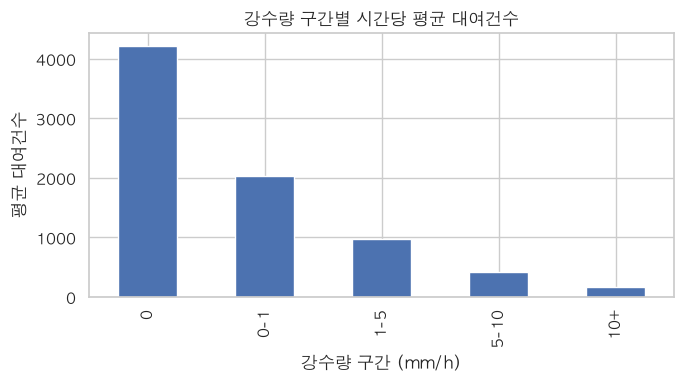

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
result.precip_bin_summary["mean"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("강수량 구간별 시간당 평균 대여건수")
ax.set_xlabel("강수량 구간 (mm/h)")
ax.set_ylabel("평균 대여건수")
plt.tight_layout()
plt.show()


기온 구간(10분위)별 평균 대여건수 — U자 형태(너무 춥거나 너무 더우면 감소, 적정 구간에서 최대) 확인.

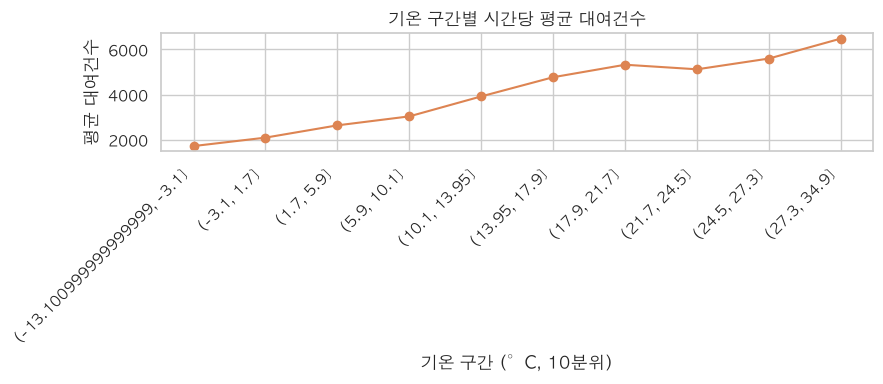

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
temp_order = result.temp_bin_summary.index.astype(str)
ax.plot(temp_order, result.temp_bin_summary["mean_rent_count"], marker="o", color="#DD8452")
ax.set_title("기온 구간별 시간당 평균 대여건수")
ax.set_xlabel("기온 구간 (°C, 10분위)")
ax.set_ylabel("평균 대여건수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**모델링 시사점**
- 강수 0mm → 10mm+ 구간까지 평균 대여건수가 단조 감소하고(Kruskal-Wallis p<0.001 수준으로 매우 유의),
  요일·시간대 계절성을 제거한 잔차 상관도 원계열과 부호·크기가 비슷하게 유지됨 — 강수-수요 관계가
  공통 계절성에 의한 허위상관이 아니라 실제 효과로 보인다. 수요 예측 모델에 강수량(연속형 또는 구간)을
  독립 피처로 넣을 가치가 충분하다.
- 강수량 구간을 그대로(binned) 넣을지 연속값으로 넣을지는 위 구간별 기울기 형태를 보고 결정 —
  0→0-1mm 구간에서 감소폭이 가장 크면 "비가 오냐 안 오냐"가 강도보다 더 중요한 신호일 수 있음
  (아래 표에서 구간별 mean 감소폭 직접 비교 필요).
- 기온은 그래프 형태를 육안으로 확인해 U자인지 단조증가인지 먼저 판단하고, U자면 기온을 그대로
  선형 피처로 넣지 말고 구간형/스플라인으로 넣는 게 맞다.


## 2. 시간 패턴 (수요 기준)

원래 계획은 재고 스냅샷의 요일×시간대 히트맵이었지만, 재고 데이터가 아직 1시간치뿐이라
의미가 없다. 대신 **수요(대여건수)** 요일×시간대 히트맵을 CSV만으로 만든다 — 대여소별
재고 소진 패턴을 가늠하는 선행 지표로 쓸 수 있다.

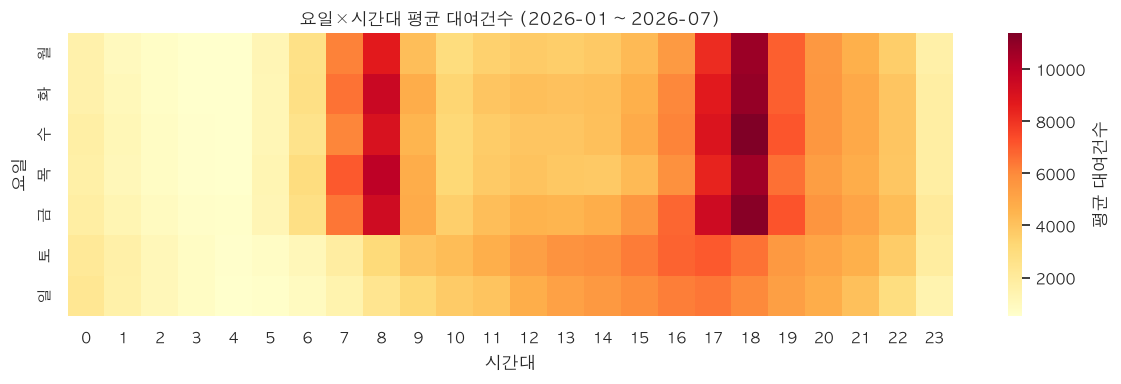

In [6]:
df = rental_hourly.copy()
df["dow"] = df["dt_hour"].dt.dayofweek  # 0=월요일
df["hour"] = df["dt_hour"].dt.hour

heatmap = df.pivot_table(index="dow", columns="hour", values="rent_count", aggfunc="mean")
heatmap.index = ["월", "화", "수", "목", "금", "토", "일"]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heatmap, ax=ax, cmap="YlOrRd", cbar_kws={"label": "평균 대여건수"})
ax.set_title("요일×시간대 평균 대여건수 (2026-01 ~ 2026-07)")
ax.set_xlabel("시간대")
ax.set_ylabel("요일")
plt.tight_layout()
plt.show()


**모델링 시사점**
- 출퇴근 피크(아침 7-9시, 저녁 18-20시) 존재 여부와 평일/주말 패턴 차이를 위 히트맵에서 직접
  확인 — 평일 피크가 뚜렷하면 "요일 유형(평일/주말) × 시간대" 교차 피처가 유용.
- 이 히트맵과 3번 섹션의 날씨 효과를 결합하면, "피크 시간대에 비가 오면 감소폭이 더 큰가"
  같은 상호작용 효과도 다음 라운드에서 검증할 수 있다 (지금은 주효과만 봄).
- 재고 데이터가 쌓이면 이 수요 히트맵과 재고 고갈률(P(N<=2)) 히트맵을 나란히 비교해서,
  "수요가 몰리는 시간대·요일이 실제로 재고 고갈로 이어지는지" 검증하는 게 다음 단계.


## 1. 재고 분포 / 4. 공간구조 — 이번 라운드 스킵

`data/BYC/raw/realtime/`에 현재 73개 스냅샷(~1시간치)만 있음 — 요일 변동조차 없는 양이라
분석 의미가 없다. 폴러가 며칠~몇 주 더 쌓이면 이 노트북에 이어서 채운다.

In [ ]:
import glob

files = sorted(glob.glob(str(AI_ROOT / "data/BYC/raw/realtime/dt=*/hh=*/snapshot_*.parquet")))
print(f"현재 스냅샷 수: {len(files)}")
if files:
    ts = pd.concat([pd.read_parquet(f)[["collected_at"]].head(1) for f in files])["collected_at"]
    print(f"수집 기간: {ts.min()} ~ {ts.max()}  ({(ts.max() - ts.min())})")